In [1]:
!pip -q install duckdb huggingface_hub scikit-learn

from google.colab import userdata
import duckdb
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import json
from pathlib import Path

from sklearn.model_selection import GroupShuffleSplit
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.metrics import roc_auc_score, average_precision_score

token = userdata.get("HF_TOKEN")

con = duckdb.connect()
con.execute("SET enable_progress_bar = false")
con.execute("SET VARIABLE hf_token = ?", [token])

con.execute("""
CREATE OR REPLACE SECRET hf (
    TYPE huggingface,
    TOKEN getvariable('hf_token')
)
""")

REL = "hf://datasets/FlyRank/internship-warehouse"
FACT = f"{REL}/fact_content_daily_performance"

MAR = f"read_parquet('{FACT}/month=2026-03/*.parquet')"
APR = f"read_parquet('{FACT}/month=2026-04/*.parquet')"

print("Capstone environment ready.")

Capstone environment ready.


# Capstone — mirrors your deployed research paper

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Malang43/flyrank-ml-internship-Malang43/blob/main/work/notebooks/capstone.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

## 1. Question

*The research question and the decision it supports.*

Title: Predicting Future Content Performance Decline for Search-Intelligence Review Prioritization

Lane: Refresh / Content Opportunity Scoring

Research question: Can observable search and engagement signals measured before a decision point help predict future content-performance decline and produce a more useful ranked page-review queue than a transparent hand-written rule?

Decision supported: A content or SEO reviewer has limited time and needs to decide which pages should be inspected first. The goal is therefore not to automatically modify pages, but to rank review candidates so that human attention is directed toward the most promising cases.

The study evaluates whether a learned model improves this prioritization task over the Week-4 rule-based baseline using the same held-out pages and the same operational metric, Precision@50.

In [2]:
study_design = pd.DataFrame({
    "Item": [
        "Lane",
        "Prediction task",
        "Unit of analysis",
        "Feature window",
        "Outcome window",
        "Primary metric"
    ],
    "Definition": [
        "Refresh / Content Opportunity Scoring",
        "Future decline probability + ranked review queue",
        "One pseudonymized client-content page",
        "March 2026",
        "April 2026",
        "Precision@50"
    ]
})

study_design

,Item,Definition
0,Lane,Refresh / Content Opportunity Scoring
1,Prediction task,Future decline probability + ranked review queue
2,Unit of analysis,One pseudonymized client-content page
3,Feature window,March 2026
4,Outcome window,April 2026
5,Primary metric,Precision@50


## 2. Data

*Which release, which tables, date windows, what you excluded and why. Public-safe.*

The analysis uses the pseudonymized FlyRank internship warehouse release. The final model uses fact_content_daily_performance, which contains daily search and analytics measurements at client-content-date grain. The March 2026 records are aggregated to one row per pseudonymized client-content page and used as the feature window; April 2026 provides the future outcome window.

Pages are retained when March contains at least 100 GSC impressions so that very low-volume percentage changes do not dominate the decline proxy. The model uses only public-safe aggregated measurements. Client names, domains, URLs, raw queries, titles, private identifiers, FlyRank product scores, product decision flags, and future-window information are excluded from predictors.

The released warehouse is a fixed pseudonymized snapshot, and its daily fact table contains an unbalanced history across clients, so availability and temporal coverage must be interpreted carefully.

In [3]:
march = con.sql(f"""
SELECT
    client_hash_id,
    content_hash_id,
    SUM(gsc_impressions) AS impressions_31d,
    SUM(gsc_clicks) AS clicks_31d,

    SUM(gsc_clicks) * 1.0 /
        NULLIF(SUM(gsc_impressions), 0) AS ctr_31d,

    SUM(gsc_sum_position) * 1.0 /
        NULLIF(SUM(gsc_impressions), 0) AS avg_position_31d,

    COALESCE(SUM(ga4_sessions), 0) AS sessions_31d

FROM {MAR}

WHERE gsc_data_available IS TRUE

GROUP BY
    client_hash_id,
    content_hash_id

HAVING SUM(gsc_impressions) >= 100
""").df()

april = con.sql(f"""
SELECT
    client_hash_id,
    content_hash_id,
    SUM(gsc_impressions) AS april_impressions

FROM {APR}

WHERE gsc_data_available IS TRUE

GROUP BY
    client_hash_id,
    content_hash_id
""").df()

model_df = march.merge(
    april,
    on=["client_hash_id", "content_hash_id"],
    how="inner"
)

model_df["future_decline"] = (
    model_df["april_impressions"] <
    0.80 * model_df["impressions_31d"]
).astype(int)

print("Modeling rows:", len(model_df))
print("Clients:", model_df["client_hash_id"].nunique())

print("\nTarget distribution:")
print(
    model_df["future_decline"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

Modeling rows: 100893
Clients: 43

Target distribution:
future_decline
1    51.48
0    48.52
Name: proportion, dtype: float64


## 3. Methodology

*Assumptions, features, label definition, baseline, validation design, leakage checks.*

Five pre-decision features are used: March impressions, clicks, CTR, average search position, and sessions. The provisional binary target is future_decline = 1 when April impressions are at least 20% lower than March impressions, and 0 otherwise. This is an operational decline proxy rather than a claim that the page itself is defective.

The transparent Week-4 baseline prioritizes visible pages using hand-written impression, position, and CTR logic. Logistic Regression is the selected final ML model because it achieved the strongest Precision@50 in the Week-5 model comparison. Random Forest and Gradient Boosting were also evaluated, but neither improved the top-50 ranking despite slightly higher ROC-AUC values.

Validation uses a client-grouped holdout so that all pages from a test client remain outside training. The grouped test contained nine unseen clients with zero overlap with the training clients. A random-row validation produced Precision@50 of 0.72, while the more conservative grouped-client result was 0.66; therefore, 0.66 is treated as the more defensible performance estimate.

Leakage checks confirmed that April impressions, the target, target-derived fields, FlyRank product outputs, and identifiers were not used as predictive features. March and April windows do not overlap.

In [4]:
features = [
    "impressions_31d",
    "clicks_31d",
    "ctr_31d",
    "avg_position_31d",
    "sessions_31d"
]

X = model_df[features].fillna(0)
y = model_df["future_decline"]
groups = model_df["client_hash_id"]

splitter = GroupShuffleSplit(
    n_splits=1,
    test_size=0.20,
    random_state=42
)

train_idx, test_idx = next(
    splitter.split(X, y, groups=groups)
)

X_train = X.iloc[train_idx]
X_test = X.iloc[test_idx]
y_train = y.iloc[train_idx]
y_test = y.iloc[test_idx]

train_clients = set(groups.iloc[train_idx])
test_clients = set(groups.iloc[test_idx])

final_model = Pipeline([
    ("scale", StandardScaler()),
    ("model", LogisticRegression(
        max_iter=2000,
        random_state=42
    ))
])

final_model.fit(X_train, y_train)

model_prob = final_model.predict_proba(X_test)[:, 1]

print("Train rows:", len(X_train))
print("Test rows:", len(X_test))
print("Train clients:", len(train_clients))
print("Test clients:", len(test_clients))
print("Client overlap:", len(train_clients & test_clients))

Train rows: 85702
Test rows: 15191
Train clients: 34
Test clients: 9
Client overlap: 0


In [5]:
forbidden = {
    "april_impressions",
    "future_decline",
    "health_score",
    "priority_score",
    "action_type",
    "label_copy_leak"
}

leaked = set(features).intersection(forbidden)

print("Final features:", features)
print("Forbidden features found:", leaked)
print("Feature/target window overlap:", False)

assert len(leaked) == 0

print("Leakage audit passed.")

Final features: ['impressions_31d', 'clicks_31d', 'ctr_31d', 'avg_position_31d', 'sessions_31d']
Forbidden features found: set()
Feature/target window overlap: False
Leakage audit passed.


## 4. Results (vs baseline)

*Model vs baseline on the same split. The honest table.*

Logistic Regression provided the strongest top-of-queue performance. Precision@50 increased from 0.48 for the transparent rule baseline to 0.66 for Logistic Regression. This corresponds to approximately 24 proxy-positive pages among the baseline's top 50 compared with approximately 33 among the Logistic Regression top 50, a relative improvement of 37.5%.

Random Forest achieved Precision@50 of 0.58 and Gradient Boosting achieved 0.56. Their ROC-AUC values were slightly higher than Logistic Regression, but the additional complexity did not improve the operational top-50 ranking. Logistic Regression was therefore retained as the final model.

This result supports improved decision prioritization within the defined experiment; it does not establish universal future performance.

In [6]:
results = pd.DataFrame({
    "Method": [
        "Week-4 Rule Baseline",
        "Logistic Regression",
        "Random Forest",
        "Gradient Boosting"
    ],
    "Precision@50": [
        0.48,
        0.66,
        0.58,
        0.56
    ],
    "ROC_AUC": [
        0.511,
        0.573,
        0.584,
        0.581
    ],
    "Average_Precision": [
        0.421,
        0.484,
        0.484,
        0.486
    ]
})

results

,Method,Precision@50,ROC_AUC,Average_Precision
0,Week-4 Rule Baseline,0.48,0.511,0.421
1,Logistic Regression,0.66,0.573,0.484
2,Random Forest,0.58,0.584,0.484
3,Gradient Boosting,0.56,0.581,0.486


In [7]:
baseline_p50 = 0.48
final_p50 = 0.66

relative_improvement = (
    (final_p50 - baseline_p50) / baseline_p50
) * 100

print(f"Baseline Precision@50: {baseline_p50:.2f}")
print(f"Logistic Regression Precision@50: {final_p50:.2f}")
print(f"Relative improvement: {relative_improvement:.1f}%")

Baseline Precision@50: 0.48
Logistic Regression Precision@50: 0.66
Relative improvement: 37.5%


## 5. Limitations

*What this work cannot claim.*

This study has several important limitations. First, the main experiment uses one March-to-April 2026 transition, so the results do not establish stability across seasons or all future periods. Second, the target is a 20% future-impression decline proxy and should not be interpreted as a definitive measure of content quality or refresh need. Third, client histories and measurement availability are unbalanced across the warehouse.

GA4 measurements are not available equally for every client and period, and the current feature construction zero-fills aggregated sessions where no value is present; this may mix genuine zero activity with unavailable analytics measurements and should be improved in future iterations.

The analysis is observational and predictive. It does not demonstrate that changing a recommended page will cause its search performance to recover. The model also does not identify Google's ranking algorithm or prove that any individual feature is a causal ranking factor.

Finally, although the grouped-client holdout is stronger than a random-row split, additional forward-in-time validation across multiple feature/outcome windows would be required before operational deployment.

## 6. Ranked recommendations

*The action playbook output — the paper's recommendations section.*

The final model is used as a decision-support ranking system. Pages are ordered by predicted probability of meeting the future-decline proxy. The first 50 pages form the primary review queue because Precision@50 matches the intended review capacity.

Reason codes provide interpretable context for human reviewers. Recommendations include reviewing weak CTR at visible positions, examining high-visibility pages with relatively weak click capture, and inspecting cases where multiple model signals combine. These are diagnostic recommendations only; content should not be automatically rewritten, merged, pruned, or deleted.

Before acting, a reviewer should consider search intent, query mix, seasonality, SERP changes, related-page consolidation, measurement availability, and traffic volume.

In [8]:
queue = model_df.iloc[test_idx][
    [
        "client_hash_id",
        "content_hash_id",
        "impressions_31d",
        "clicks_31d",
        "ctr_31d",
        "avg_position_31d",
        "sessions_31d"
    ]
].copy()

queue["model_score"] = model_prob

train_frame = model_df.iloc[train_idx]

ctr_q25 = train_frame["ctr_31d"].quantile(0.25)
ctr_median = train_frame["ctr_31d"].median()
clicks_q25 = train_frame["clicks_31d"].quantile(0.25)

def reason_code(row):
    if (
        row["avg_position_31d"] <= 20
        and row["ctr_31d"] <= ctr_q25
    ):
        return "low_ctr_at_visible_position"

    elif (
        row["impressions_31d"] >= 500
        and row["clicks_31d"] <= clicks_q25
    ):
        return "high_visibility_low_clicks"

    elif (
        row["avg_position_31d"] <= 10
        and row["ctr_31d"] <= ctr_median
    ):
        return "page_one_click_gap"

    return "combined_model_signal"

queue["reason_code"] = queue.apply(reason_code, axis=1)

queue = queue.sort_values(
    "model_score",
    ascending=False
).reset_index(drop=True)

queue["rank"] = np.arange(1, len(queue) + 1)

queue["action"] = np.select(
    [
        queue["rank"] <= 50,
        queue["rank"] <= 200
    ],
    [
        "review_now",
        "review_if_capacity"
    ],
    default="monitor"
)

display(
    queue[
        [
            "rank",
            "content_hash_id",
            "model_score",
            "reason_code",
            "action",
            "impressions_31d",
            "ctr_31d",
            "avg_position_31d"
        ]
    ].head(20)
)

,rank,content_hash_id,model_score,reason_code,action,impressions_31d,ctr_31d,avg_position_31d
0,1,content_9d9713f2a48067c8,0.717063,low_ctr_at_visible_position,review_now,771.0,0.000000,10.992218
1,2,content_c0407691d2c3c153,0.673936,page_one_click_gap,review_now,2482.0,0.000403,7.605963
2,3,content_cd3d932d4e1c8db0,0.671890,page_one_click_gap,review_now,89332.0,0.000045,7.831807
3,4,content_d8288f22519f7d53,0.660219,high_visibility_low_clicks,review_now,1225.0,0.000000,21.675918
4,5,content_2b74174acd8039c7,0.652543,low_ctr_at_visible_position,review_now,832.0,0.000000,7.974760
5,6,content_cf2264753938463b,0.649439,page_one_click_gap,review_now,46938.0,0.000234,4.260194
6,7,content_713b157e9c77690a,0.645506,low_ctr_at_visible_position,review_now,24908.0,0.000000,3.431106
7,8,content_dc91779c3d085398,0.643148,page_one_click_gap,review_now,25625.0,0.000039,2.389151
8,9,content_b215e9a73e2284ad,0.641889,low_ctr_at_visible_position,review_now,930.0,0.000000,13.822581
9,10,content_5b9f20eb3b7f872b,0.638169,page_one_click_gap,review_now,17617.0,0.000114,3.808764


## 7. Artifacts the paper embeds

*Generate/collect the charts and tables your deployed page will show.*

In [9]:
output_dir = Path("../outputs")
output_dir.mkdir(parents=True, exist_ok=True)

print("Output folder ready:", output_dir)

Output folder ready: ../outputs


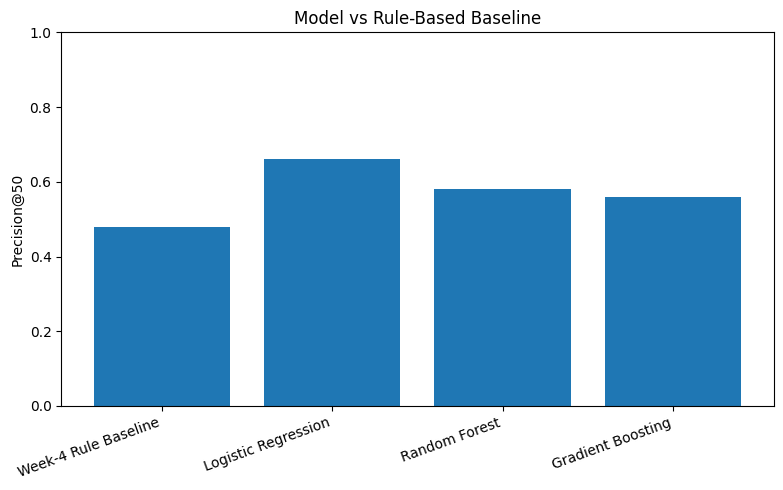

In [10]:
fig, ax = plt.subplots(figsize=(8, 5))

ax.bar(
    results["Method"],
    results["Precision@50"]
)

ax.set_ylabel("Precision@50")
ax.set_title("Model vs Rule-Based Baseline")
ax.set_ylim(0, 1)

plt.xticks(rotation=20, ha="right")
plt.tight_layout()

fig.savefig(
    output_dir / "capstone_model_comparison.png",
    dpi=200,
    bbox_inches="tight"
)

plt.show()

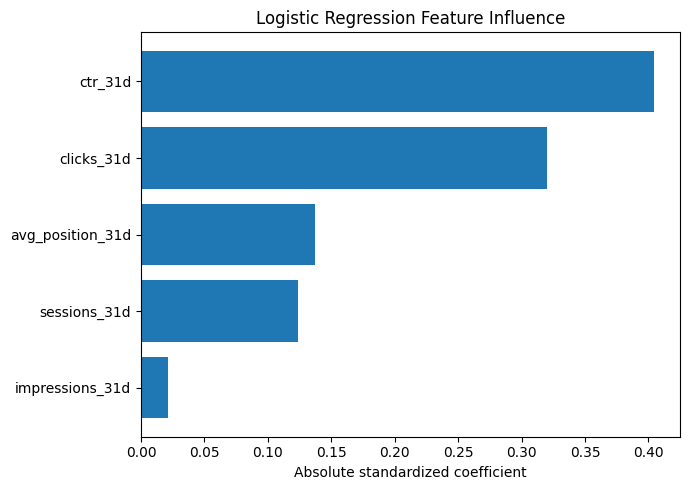

,Feature,Coefficient,Absolute_Coefficient
0,impressions_31d,0.021196,0.021196
4,sessions_31d,0.123529,0.123529
3,avg_position_31d,-0.137434,0.137434
1,clicks_31d,-0.319893,0.319893
2,ctr_31d,-0.404612,0.404612


In [11]:
coef = pd.DataFrame({
    "Feature": features,
    "Coefficient": final_model
        .named_steps["model"]
        .coef_[0]
})

coef["Absolute_Coefficient"] = coef["Coefficient"].abs()

coef = coef.sort_values(
    "Absolute_Coefficient",
    ascending=True
)

fig, ax = plt.subplots(figsize=(7, 5))

ax.barh(
    coef["Feature"],
    coef["Absolute_Coefficient"]
)

ax.set_xlabel("Absolute standardized coefficient")
ax.set_title("Logistic Regression Feature Influence")

plt.tight_layout()

fig.savefig(
    output_dir / "capstone_feature_coefficients.png",
    dpi=200,
    bbox_inches="tight"
)

plt.show()

coef

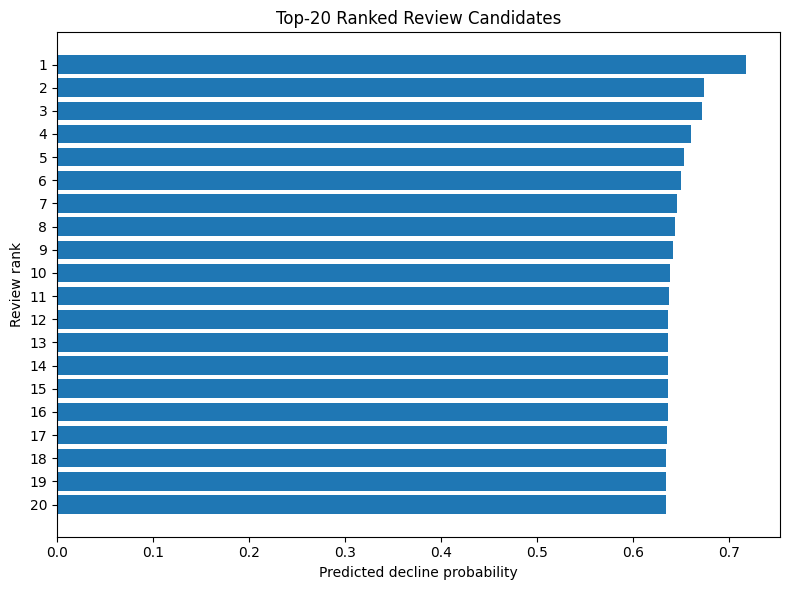

In [12]:
top20 = queue.head(20).copy()

fig, ax = plt.subplots(figsize=(8, 6))

ax.barh(
    top20["rank"].astype(str),
    top20["model_score"]
)

ax.invert_yaxis()
ax.set_xlabel("Predicted decline probability")
ax.set_ylabel("Review rank")
ax.set_title("Top-20 Ranked Review Candidates")

plt.tight_layout()

fig.savefig(
    output_dir / "capstone_top20_scores.png",
    dpi=200,
    bbox_inches="tight"
)

plt.show()

In [13]:
capstone_metrics = {
    "title": "Predicting Future Content Performance Decline for Search-Intelligence Review Prioritization",
    "lane": "Refresh / Content Opportunity Scoring",
    "model": "Logistic Regression",
    "feature_window": "March 2026",
    "outcome_window": "April 2026",
    "modeling_rows": int(len(model_df)),
    "validation_design": "client-grouped holdout",
    "test_clients": int(len(test_clients)),
    "client_overlap": int(len(train_clients & test_clients)),
    "baseline_precision_at_50": 0.48,
    "logistic_precision_at_50": 0.66,
    "random_forest_precision_at_50": 0.58,
    "gradient_boosting_precision_at_50": 0.56,
    "relative_improvement_pct": 37.5,
    "features": features
}

with open(
    output_dir / "capstone_metrics.json",
    "w"
) as f:
    json.dump(capstone_metrics, f, indent=2)

print("Saved capstone_metrics.json")

Saved capstone_metrics.json


In [14]:
queue.to_csv(
    output_dir / "capstone_ranked_recommendations.csv",
    index=False
)

print("Ranked queue generated.")

Ranked queue generated.


## Self-check

Before you submit, confirm each line honestly:

- [ ] Every section above is filled — markdown thinking AND the code that backs it
- [ ] The notebook runs top to bottom with no errors (Runtime → Run all)
- [ ] No client names, URLs, or private queries anywhere
- [ ] My claims use careful words: observed, measured, directional, decision-support
- [ ] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.
- [ ] My deployed paper has **all 9 sections** — including the **Abstract** at the top and **Acknowledgments & data credit** (the https://flyrank.ai link) at the bottom.
- [ ] **ML-12 done in this notebook's closing cells:** 5-minute demo outline + a social-post cut + a 3-sentence employer-facing summary.
